In [56]:
import pandas as pd
import numpy as np
import pandas_ta as ta
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import joblib

In [57]:
df = pd.read_csv('USDCAD_M15_20241231.csv', parse_dates=["Date"], index_col=0)

In [58]:
# target calculation
df['returns'] = df['Close'].pct_change()
df['target'] = (df['returns'] > 0).astype(int)
df['s_returns'] = df['returns']
df['cumulative_buy_and_hold_returns'] = df["returns"].cumsum().apply(np.exp)

# Shift price and returns to prevent lookahead bias
df['Close'] = df['Close'].shift(1)
df['Open'] = df['Open'].shift(1)
df['High'] = df['High'].shift(1)
df['Low'] = df['Low'].shift(1)
df['returns'] = df['returns'].shift(1)
df['volatility'] = df['returns'].rolling(window=8).std()
df['returns_div_volatility'] = df['returns'] / df['volatility'].replace(0, np.nan)
df['returns_inv'] = 1 / df['returns'].replace(0, np.nan)
df['volatility_inv'] = 1 / df['volatility'].replace(0, np.nan)
# df[['stoch_k', 'stoch_d']] = ta.stoch(df['High'], df['Low'], df['Close'], 13, 3, 3)
# df['stoch'] = np.where(
#     (df['stoch_k'] > df['stoch_d']) & (df['stoch_k'] <= 20), 1,
#     np.where((df['stoch_k'] < df['stoch_d']) & (df['stoch_k'] >= 80), -1, 0)
# )

df[["lower", "mid","upper","bandwidth","percent"]] = ta.bbands(df["Close"], length=21, std=2)
df['distance'] = df['Close'] - df['mid']
df["position"] = np.where(df.Close < df.lower, 1, np.nan) # 1. oversold -> go long
df["position"] = np.where(df.Close > df.upper, -1, df["position"]) # 2. overbought -> go short
df["position"] = np.where(df.distance * df.distance.shift(1) < 0, 0, df["position"]) # 3. crossing SMA ("Middle Band") -> go neutral
df["position"] = df.position.ffill().fillna(0)
df.dropna(inplace=True)

#HMM
feature_matrix = df[['returns', 'volatility']]
scaler_hmm = StandardScaler()
feature_matrix_scaled = scaler_hmm.fit_transform(feature_matrix)
hmm_model = GaussianHMM(n_components = 5, covariance_type="full", n_iter = 100 , random_state=42)
hmm_model.fit(feature_matrix_scaled)
df['hmm_regime'] = hmm_model.predict(feature_matrix_scaled)
probabilities = hmm_model.predict_proba(feature_matrix_scaled)
df['hmm_prob_0'] = probabilities[:, 0]
df['hmm_prob_1'] = probabilities[:, 1]
df['hmm_prob_2'] = probabilities[:, 2]
df['hmm_prob_3'] = probabilities[:, 3]
df['hmm_prob_4'] = probabilities[:, 4]

# Final clean up
df.replace([np.inf, -np.inf], 0, inplace=True)
df.dropna(inplace=True)

In [59]:
# features
features = df.drop(columns=['target', 's_returns', 'cumulative_buy_and_hold_returns', 'Close', 'Open', 'High', 'Low',"lower", "mid","upper","bandwidth","percent",'distance', 'position']).columns

# Define features and target
X = df[features]
y = df["target"]

# Apply StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Convert the scaled NumPy array back to a DataFrame
X = pd.DataFrame(X, columns=features)

In [60]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_clf = RandomForestClassifier(n_estimators=500,
                                max_depth=5,
                                class_weight = 'balanced',
                                random_state=42)

model = rf_clf

# Train the model on the training set
model.fit(X_train, y_train)

# Predict and calculate accuracy for training and testing sets
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

accuracy_train = accuracy_score(y_train, y_pred_train) * 100
accuracy_test = accuracy_score(y_test, y_pred_test) * 100

# Print train and test accuracy
print(f"Train Accuracy: {accuracy_train:.2f}")
print(f"Test Accuracy: {accuracy_test:.2f}")

# Predict on the entire dataset
df['pred'] = model.predict(X)
total_accuracy = accuracy_score(df.target, df.pred) * 100
print(f"Total Accuracy: {total_accuracy:.2f}")

# Get predicted probabilities for each class
probs = model.predict_proba(X)

# Add these probabilities to the dataframe
df['prob_class_-1'] = probs[:, 0]
df['prob_class_1'] = probs[:, 1]
df['prob'] = np.where(df['prob_class_1'] > df['prob_class_-1'], df['prob_class_1'], df['prob_class_-1'])

Train Accuracy: 55.16
Test Accuracy: 54.18
Total Accuracy: 54.96


In [80]:
C_wlr_th = 0.987
C_raw_accuracy_th = 54
C_filtered_accuracy_th = 55
C_sharp_ratio_th = 10
C_max_dd_th = 0.02
C_position_count_th = 27000
C_cumulative_th = 2.4
C_annual_th = 0.78

In [81]:
objects_to_save = {
    'clf': model,
    'hmm': hmm_model,
    'scaler': scaler,
    'scaler_hmm': scaler_hmm,
    'wlr': C_wlr_th,
    'raw_accuracy': C_raw_accuracy_th,
    'filtered_accuracy': C_filtered_accuracy_th,
    'sharp_ratio': C_sharp_ratio_th,
    'max_dd': C_max_dd_th,
    'position_count': C_position_count_th,
    'cumulative': C_cumulative_th,
    'annual' : C_annual_th}
joblib.dump(objects_to_save, 'U_C.joblib')

['U_C.joblib']

# Filter and Evaluations

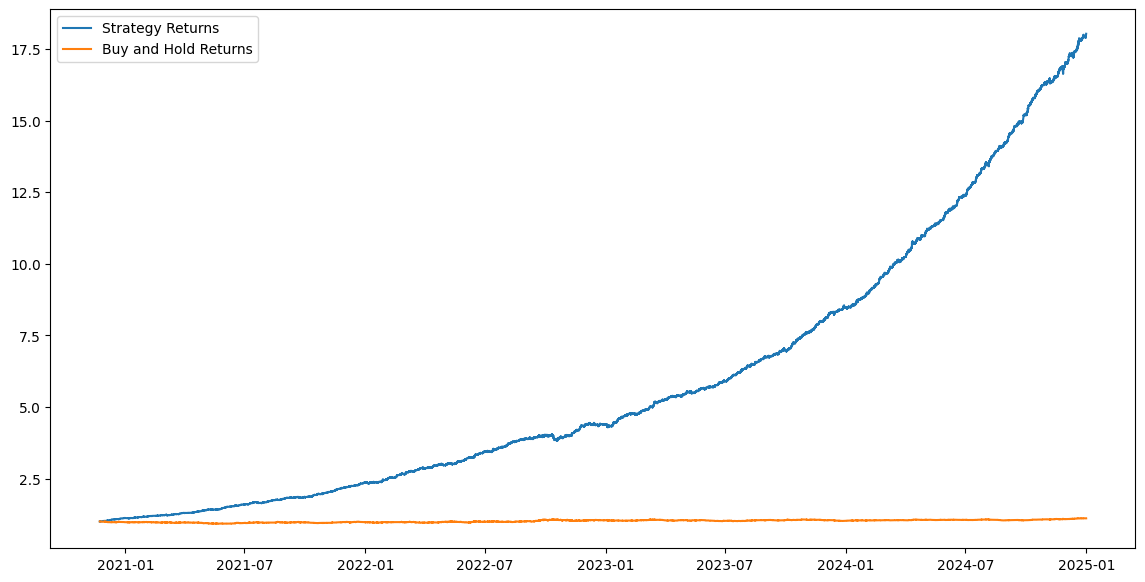

In [61]:
# strategy
df['pred'] = df['pred'].map({0: -1, 1: 1})
df['strategy'] = df['pred'] * df['s_returns']
df['cumulative_strategy_returns'] = df["strategy"].cumsum().apply(np.exp)

# plot
plt.figure(figsize=(14,7))
plt.plot(df['cumulative_strategy_returns'], label=f'Strategy Returns')
plt.plot(df['cumulative_buy_and_hold_returns'], label=f'Buy and Hold Returns')
plt.legend()
plt.show()

In [62]:
# Actual returns associated with each trade
annualized_factor = 24960  # The number of 15-minute bars in a year
annualized_sreturn = np.mean(df['strategy']) * annualized_factor
print(f"Annualized Strategy Return: {annualized_sreturn:.2f}")

# Sharpe Ratio
risk_free_rate = 0  # Assuming risk-free rate is 0 for simplicity
mean_return = np.mean(df['strategy']) * annualized_factor
std_return = np.std(df['strategy']) * np.sqrt(annualized_factor)
sharpe_ratio = (mean_return - risk_free_rate) / std_return
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")


# Maximum Drawdown
def max_drawdown(strategy_returns):
    cumulative = np.cumsum(strategy_returns)
    drawdown = cumulative - np.maximum.accumulate(cumulative)
    return np.min(drawdown)

max_dd = max_drawdown(df['strategy'])
print(f"Maximum Drawdown: {max_dd:.2f}")

Annualized Strategy Return: 0.73
Annualized Sharpe Ratio: 10.54
Maximum Drawdown: -0.06


In [63]:
print(df.target.value_counts())
print(df.pred.value_counts())
print(df.position.value_counts())

target
0    50059
1    48663
Name: count, dtype: int64
pred
-1    50179
 1    48543
Name: count, dtype: int64
position
 0.0    46087
-1.0    26707
 1.0    25928
Name: count, dtype: int64


In [64]:
# Calculate wins and losses, treating losses as positive values
df['loss'] = np.where(df['strategy'] < 0, abs(df['strategy']), np.nan)
df['win'] = np.where(df['strategy'] > 0, df['strategy'], np.nan)

# Calculate the average win-to-loss ratio
win_loss_ratio = df['win'].mean() / df['loss'].mean()

# Handle cases where loss is zero or NaN
win_loss_ratio = np.where(np.isnan(win_loss_ratio) | (win_loss_ratio == 0), 1, win_loss_ratio)

# Calculate the Kelly Criterion using the improved formula
df['kelly'] = (df['prob'] - (1 - df['prob']) / win_loss_ratio)
win_loss_ratio

array(0.99611464)

In [65]:
df.describe()

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
count,98722.000000,98722.000000,98722.000000,98722.000000,98722.000000,98722.000000,9.872200e+04,98722.000000,98722.000000,98722.000000,...,9.872200e+04,98722.000000,98722.000000,98722.000000,98722.000000,98722.000000,98722.000000,43818.000000,53669.000000,98722.000000
mean,1.317395,1.317781,1.317016,1.317397,0.000001,0.492930,9.321226e-07,1.012028,0.000369,0.001370,...,2.504878e-01,-0.016572,0.500004,0.499996,0.518445,0.000029,5.843713,0.000300,0.000299,0.035013
std,0.051801,0.051789,0.051814,0.051803,0.000442,0.499953,4.402264e-04,0.042606,0.000241,1.034288,...,4.067163e-01,0.999868,0.027773,0.027773,0.020763,0.000439,4.535096,0.000333,0.000321,0.041606
min,1.200820,1.201920,1.200560,1.200830,-0.009539,0.000000,-9.539265e-03,0.918527,0.000022,-4.042294,...,0.000000e+00,-1.000000,0.375829,0.203536,0.500000,-0.010898,1.000138,0.000007,0.000007,-0.001950
25%,1.269920,1.270330,1.269530,1.269930,-0.000206,0.000000,-2.028713e-04,0.971992,0.000211,-0.701261,...,8.057435e-17,-1.000000,0.483471,0.488344,0.508490,-0.000165,2.193258,0.000087,0.000096,0.015064
50%,1.333970,1.334400,1.333600,1.333975,-0.000007,0.000000,0.000000e+00,1.026338,0.000313,-0.013781,...,2.298078e-06,-1.000000,0.501048,0.498952,0.513395,0.000032,4.340987,0.000198,0.000212,0.024892
75%,1.359890,1.360280,1.359520,1.359880,0.000205,1.000000,2.025993e-04,1.047043,0.000459,0.698166,...,5.507289e-01,1.000000,0.511656,0.516529,0.519067,0.000235,8.331365,0.000401,0.000397,0.036257
max,1.446090,1.446620,1.445440,1.446120,0.010898,1.000000,1.089806e-02,1.115469,0.004344,4.205789,...,1.000000e+00,1.000000,0.796464,0.624171,0.796464,0.009539,18.033539,0.010898,0.009539,0.592134


In [66]:
df_filtered = df[((df['position'] == 1) & (df['pred'] == 1)) | ((df['position'] == -1) & (df['pred'] == -1))].copy()

In [67]:
df_filtered

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
Date,,,,,,,,,,,,,,,,,,,,,
2020-11-23 10:00:00,1.30730,1.30740,1.30650,1.30658,-0.000551,0,-0.000850,0.997365,0.000281,-1.960695,...,2.096912e-05,1,0.474060,0.525940,0.525940,-0.000850,1.000635,0.000850,NaN,0.050030
2020-11-23 10:15:00,1.30658,1.30671,1.30489,1.30547,-0.000850,0,-0.000268,0.997098,0.000395,-2.152756,...,4.280424e-16,1,0.466915,0.533085,0.533085,-0.000268,1.000367,0.000268,NaN,0.064349
2020-11-23 10:30:00,1.30547,1.30584,1.30505,1.30512,-0.000268,1,0.000169,0.997266,0.000381,-0.703822,...,1.050494e-10,1,0.478053,0.521947,0.521947,0.000169,1.000535,NaN,0.000169,0.042029
2020-11-23 11:00:00,1.30534,1.30542,1.30454,1.30471,-0.000483,0,0.000000,0.996785,0.000384,-1.255824,...,5.833552e-13,1,0.476987,0.523013,0.523013,0.000000,1.001018,NaN,NaN,0.044166
2020-11-23 12:00:00,1.30549,1.30567,1.30504,1.30506,-0.000329,1,0.000054,0.997106,0.000434,-0.759393,...,1.731980e-14,1,0.484326,0.515674,0.515674,0.000054,1.000834,NaN,0.000054,0.029458
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 10:00:00,1.43621,1.43694,1.43614,1.43674,0.000369,1,0.000487,1.108819,0.000255,1.447569,...,7.652577e-04,-1,0.512311,0.487689,0.512311,-0.000487,18.010841,0.000487,NaN,0.022719
2024-12-31 10:15:00,1.43672,1.43750,1.43671,1.43744,0.000487,1,0.000285,1.109135,0.000276,1.765488,...,2.412160e-05,-1,0.513718,0.486282,0.513718,-0.000285,18.005704,0.000285,NaN,0.025539
2024-12-31 10:30:00,1.43743,1.43787,1.43735,1.43785,0.000285,0,-0.000591,1.108480,0.000276,1.031745,...,1.346366e-04,-1,0.516120,0.483880,0.516120,0.000591,18.016352,NaN,0.000591,0.030352


In [68]:
df_filtered['pred'] = df_filtered['pred'].map({-1: 0, 1: 1})
accuracy = accuracy_score(df_filtered.target, df_filtered.pred) * 100
accuracy

54.738124238733256

In [69]:
print(df_filtered.target.value_counts())
print(df_filtered.pred.value_counts())
print(df_filtered.position.value_counts())

target
0    14438
1    14297
Name: count, dtype: int64
pred
0    15128
1    13607
Name: count, dtype: int64
position
-1.0    15128
 1.0    13607
Name: count, dtype: int64


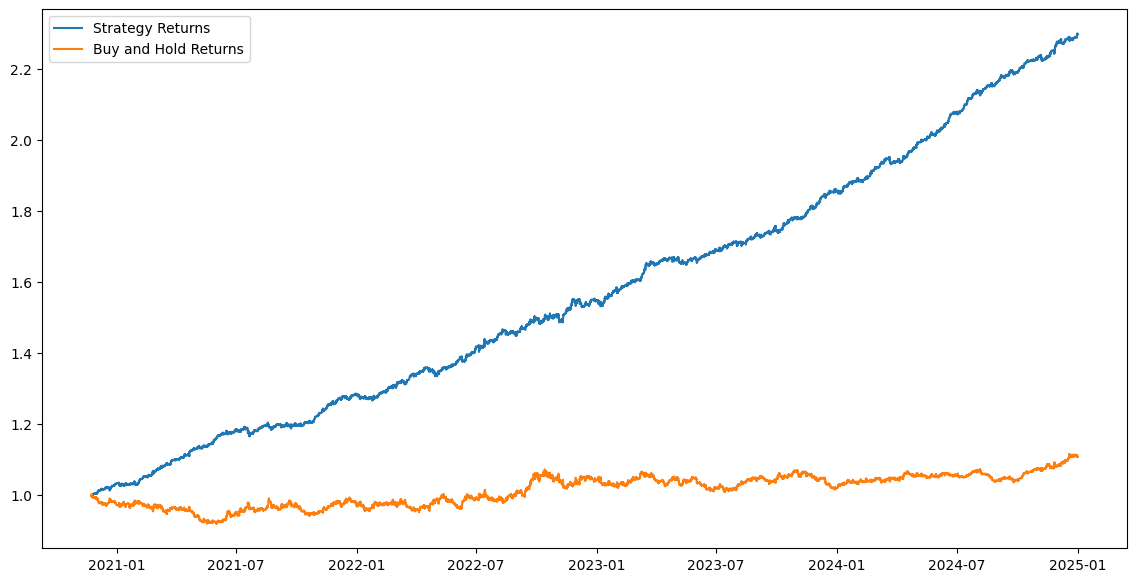

In [70]:
# strategy
df_filtered['pred'] = df_filtered['pred'].map({0: -1, 1: 1})
df_filtered['strategy'] = df_filtered['pred'] * df_filtered['s_returns']
df_filtered['cumulative_strategy_returns'] = df_filtered["strategy"].cumsum().apply(np.exp)

# plot
plt.figure(figsize=(14,7))
plt.plot(df_filtered['cumulative_strategy_returns'], label=f'Strategy Returns')
plt.plot(df_filtered['cumulative_buy_and_hold_returns'], label=f'Buy and Hold Returns')
plt.legend()
plt.show()

In [71]:
# Actual returns associated with each trade
annualized_factor = 24960  # The number of 15-minute bars in a year
annualized_sreturn = np.mean(df_filtered['strategy']) * annualized_factor
print(f"Annualized Strategy Return: {annualized_sreturn:.2f}")

# Sharpe Ratio
risk_free_rate = 0  # Assuming risk-free rate is 0 for simplicity
mean_return = np.mean(df_filtered['strategy']) * annualized_factor
std_return = np.std(df_filtered['strategy']) * np.sqrt(annualized_factor)
sharpe_ratio = (mean_return - risk_free_rate) / std_return
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")


# Maximum Drawdown
def max_drawdown(strategy_returns):
    cumulative = np.cumsum(strategy_returns)
    drawdown = cumulative - np.maximum.accumulate(cumulative)
    return np.min(drawdown)

max_dd = max_drawdown(df_filtered['strategy'])
print(f"Maximum Drawdown: {max_dd:.2f}")

Annualized Strategy Return: 0.72
Annualized Sharpe Ratio: 9.83
Maximum Drawdown: -0.02


In [72]:
# Calculate wins and losses, treating losses as positive values
df_filtered['loss'] = np.where(df_filtered['strategy'] < 0, abs(df_filtered['strategy']), np.nan)
df_filtered['win'] = np.where(df_filtered['strategy'] > 0, df_filtered['strategy'], np.nan)

# Calculate the average win-to-loss ratio
win_loss_ratio = df_filtered['win'].mean() / df_filtered['loss'].mean()

# Handle cases where loss is zero or NaN
win_loss_ratio = np.where(np.isnan(win_loss_ratio) | (win_loss_ratio == 0), 1, win_loss_ratio)

# Calculate the Kelly Criterion using the improved formula
df_filtered['kelly'] = (df_filtered['prob'] - (1 - df_filtered['prob']) / win_loss_ratio)
win_loss_ratio

array(0.98847101)

In [73]:
df_filtered.describe()

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
count,28735.000000,28735.000000,28735.000000,28735.000000,28735.000000,28735.000000,28735.000000,28735.000000,28735.000000,28735.000000,...,2.873500e+04,28735.000000,28735.000000,28735.000000,28735.000000,28735.000000,28735.000000,12829.000000,15565.000000,28735.000000
mean,1.316591,1.317027,1.316176,1.316605,0.000010,0.497547,0.000002,1.011328,0.000392,-0.001746,...,2.029267e-01,-0.052932,0.499060,0.500940,0.518177,0.000029,1.555407,0.000326,0.000322,0.030735
std,0.051364,0.051360,0.051381,0.051379,0.000508,0.500003,0.000466,0.042255,0.000250,1.144238,...,3.777363e-01,0.998615,0.026435,0.026435,0.019216,0.000466,0.356324,0.000342,0.000338,0.038656
min,1.201840,1.202020,1.200560,1.200830,-0.009113,0.000000,-0.009539,0.918527,0.000022,-4.042294,...,0.000000e+00,-1.000000,0.375829,0.219774,0.500001,-0.004433,0.996802,0.000007,0.000007,-0.005829
25%,1.270445,1.270900,1.270000,1.270495,-0.000233,0.000000,-0.000220,0.972348,0.000231,-0.775336,...,1.662658e-19,-1.000000,0.483100,0.488158,0.508757,-0.000185,1.259022,0.000096,0.000108,0.011785
50%,1.330290,1.330690,1.329740,1.330310,0.000007,0.000000,0.000000,1.023364,0.000335,0.019420,...,1.468464e-07,-1.000000,0.502835,0.497165,0.513388,0.000033,1.516203,0.000221,0.000231,0.021101
75%,1.359570,1.360010,1.359170,1.359620,0.000252,1.000000,0.000226,1.046781,0.000485,0.772498,...,6.445244e-02,1.000000,0.511842,0.516900,0.519008,0.000255,1.813144,0.000440,0.000426,0.032406
max,1.445570,1.446620,1.445440,1.446120,0.010898,1.000000,0.005895,1.115469,0.004344,3.855552,...,1.000000e+00,1.000000,0.780226,0.624171,0.780226,0.009539,2.299096,0.004433,0.009539,0.557889


In [74]:
df

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
Date,,,,,,,,,,,,,,,,,,,,,
2020-11-23 04:30:00,1.30691,1.30720,1.30684,1.30700,0.000069,1,0.000138,0.998671,0.000177,0.388251,...,1.000000e+00,1,0.450703,0.549297,0.549297,0.000138,1.000138,NaN,0.000138,0.096836
2020-11-23 04:45:00,1.30700,1.30734,1.30686,1.30718,0.000138,0,-0.000191,0.998480,0.000191,0.720192,...,9.868873e-01,-1,0.525802,0.474198,0.525802,0.000191,1.000329,NaN,0.000191,0.049754
2020-11-23 05:00:00,1.30717,1.30720,1.30684,1.30693,-0.000191,0,-0.000153,0.998327,0.000197,-0.969040,...,8.049707e-01,-1,0.520899,0.479101,0.520899,0.000153,1.000482,NaN,0.000153,0.039929
2020-11-23 05:15:00,1.30689,1.30711,1.30673,1.30673,-0.000153,1,0.000245,0.998572,0.000122,-1.257855,...,9.980724e-01,1,0.486059,0.513941,0.513941,0.000245,1.000727,NaN,0.000245,0.025986
2020-11-23 05:30:00,1.30674,1.30708,1.30670,1.30705,0.000245,0,-0.000023,0.998549,0.000149,1.648056,...,9.976230e-01,1,0.471250,0.528750,0.528750,-0.000023,1.000704,0.000023,NaN,0.055663
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 10:45:00,1.43785,1.43787,1.43688,1.43700,-0.000591,0,-0.000070,1.108402,0.000397,-1.488664,...,3.308220e-13,1,0.476946,0.523054,0.523054,-0.000070,18.015098,0.000070,NaN,0.044249
2024-12-31 11:00:00,1.43700,1.43757,1.43673,1.43690,-0.000070,0,-0.000209,1.108171,0.000385,-0.180665,...,3.718839e-09,-1,0.507830,0.492170,0.507830,0.000209,18.018860,NaN,0.000209,0.013741
2024-12-31 11:15:00,1.43690,1.43698,1.43658,1.43660,-0.000209,1,0.000285,1.108487,0.000367,-0.568429,...,4.331583e-09,1,0.483754,0.516246,0.516246,0.000285,18.024003,NaN,0.000285,0.030605


In [75]:
df_filtered_2 = df_filtered[(df_filtered['kelly'] > 0)].copy()
df_filtered_2['pred'] = df_filtered_2['pred'].map({-1: 0, 1: 1})
accuracy = accuracy_score(df_filtered_2.target, df_filtered_2.pred) * 100
accuracy


# df_filtered_2 = df[((df['position'] == 1) & (df['kelly'] > 0)) | ((df['position'] == -1) & (df['kelly'] > 0))].copy()
# df_filtered_2['position'] = df_filtered_2['position'].map({-1: 0, 1: 1})
# accuracy = accuracy_score(df_filtered_2.target, df_filtered_2.position) * 100
# accuracy

55.04849039341263

In [76]:
df_filtered_2

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
Date,,,,,,,,,,,,,,,,,,,,,
2020-11-23 10:00:00,1.30730,1.30740,1.30650,1.30658,-0.000551,0,-0.000850,0.997365,0.000281,-1.960695,...,2.096912e-05,1,0.474060,0.525940,0.525940,-0.000850,0.999151,0.000850,NaN,0.046350
2020-11-23 10:15:00,1.30658,1.30671,1.30489,1.30547,-0.000850,0,-0.000268,0.997098,0.000395,-2.152756,...,4.280424e-16,1,0.466915,0.533085,0.533085,-0.000268,0.998883,0.000268,NaN,0.060725
2020-11-23 10:30:00,1.30547,1.30584,1.30505,1.30512,-0.000268,1,0.000169,0.997266,0.000381,-0.703822,...,1.050494e-10,1,0.478053,0.521947,0.521947,0.000169,0.999051,NaN,0.000169,0.038318
2020-11-23 11:00:00,1.30534,1.30542,1.30454,1.30471,-0.000483,0,0.000000,0.996785,0.000384,-1.255824,...,5.833552e-13,1,0.476987,0.523013,0.523013,0.000000,0.999051,NaN,NaN,0.040463
2020-11-23 12:00:00,1.30549,1.30567,1.30504,1.30506,-0.000329,1,0.000054,0.997106,0.000434,-0.759393,...,1.731980e-14,1,0.484326,0.515674,0.515674,0.000054,0.999105,NaN,0.000054,0.025699
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 10:00:00,1.43621,1.43694,1.43614,1.43674,0.000369,1,0.000487,1.108819,0.000255,1.447569,...,7.652577e-04,0,0.512311,0.487689,0.512311,-0.000487,2.297162,0.000487,NaN,0.018933
2024-12-31 10:15:00,1.43672,1.43750,1.43671,1.43744,0.000487,1,0.000285,1.109135,0.000276,1.765488,...,2.412160e-05,0,0.513718,0.486282,0.513718,-0.000285,2.296506,0.000285,NaN,0.021764
2024-12-31 10:30:00,1.43743,1.43787,1.43735,1.43785,0.000285,0,-0.000591,1.108480,0.000276,1.031745,...,1.346366e-04,0,0.516120,0.483880,0.516120,0.000591,2.297864,NaN,0.000591,0.026595


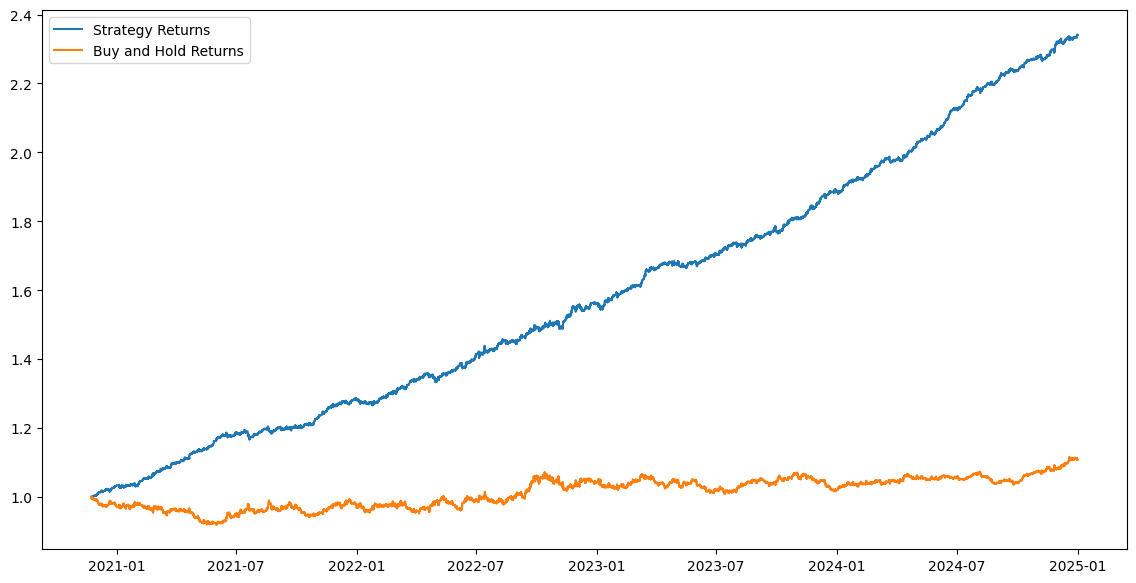

In [77]:
# strategy
df_filtered_2['pred'] = df_filtered_2['pred'].map({0: -1, 1: 1})
df_filtered_2['strategy'] = df_filtered_2['pred'] * df_filtered_2['s_returns']
df_filtered_2['cumulative_strategy_returns'] = df_filtered_2["strategy"].cumsum().apply(np.exp)

# plot
plt.figure(figsize=(14,7))
plt.plot(df_filtered_2['cumulative_strategy_returns'], label=f'Strategy Returns')
plt.plot(df_filtered_2['cumulative_buy_and_hold_returns'], label=f'Buy and Hold Returns')
plt.legend()
plt.show()

In [78]:
# Calculate wins and losses, treating losses as positive values
df_filtered_2['loss'] = np.where(df_filtered_2['strategy'] < 0, abs(df_filtered_2['strategy']), np.nan)
df_filtered_2['win'] = np.where(df_filtered_2['strategy'] > 0, df_filtered_2['strategy'], np.nan)

# Calculate the average win-to-loss ratio
win_loss_ratio = df_filtered_2['win'].mean() / df_filtered_2['loss'].mean()

# Handle cases where loss is zero or NaN
win_loss_ratio = np.where(np.isnan(win_loss_ratio) | (win_loss_ratio == 0), 1, win_loss_ratio)

# Calculate the Kelly Criterion using the improved formula
df_filtered_2['kelly'] = (df_filtered_2['prob'] - (1 - df_filtered_2['prob']) / win_loss_ratio)
win_loss_ratio

array(0.9879443)

In [79]:
# Actual returns associated with each trade
annualized_factor = 24960  # The number of 15-minute bars in a year
annualized_sreturn = np.mean(df_filtered_2['strategy']) * annualized_factor
print(f"Annualized Strategy Return: {annualized_sreturn:.2f}")

# Sharpe Ratio
risk_free_rate = 0  # Assuming risk-free rate is 0 for simplicity
mean_return = np.mean(df_filtered_2['strategy']) * annualized_factor
std_return = np.std(df_filtered_2['strategy']) * np.sqrt(annualized_factor)
sharpe_ratio = (mean_return - risk_free_rate) / std_return
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")


# Maximum Drawdown
def max_drawdown(strategy_returns):
    cumulative = np.cumsum(strategy_returns)
    drawdown = cumulative - np.maximum.accumulate(cumulative)
    return np.min(drawdown)

max_dd = max_drawdown(df_filtered_2['strategy'])
print(f"Maximum Drawdown: {max_dd:.2f}")

Annualized Strategy Return: 0.78
Annualized Sharpe Ratio: 10.54
Maximum Drawdown: -0.02
